<h1>Pre-training of Language Models</h1>
<p>
Pre-training is a technique used in natural language processing to train a language model on a large amount of unlabeled text data before fine-tuning it on a specific task. The goal of pre-training is to create a model that can learn the structure and patterns of language, allowing it to develop a deep understanding of the language and generate coherent and contextually relevant responses.

Fine-tuning a pre-trained language model involves training the model on a smaller labeled dataset specific to the task, such as sentiment analysis, text classification, or named entity recognition. The pre-trained model is then adapted to the specific task, resulting in improved performance on that task. For example, a pre-trained model might be fine-tuned on a sentiment analysis task to classify movie reviews as positive or negative.

Several pre-trained language models have shown significant improvements when fine-tuned on specific tasks. BERT (Bidirectional Encoder Representations from Transformers), a pre-trained model developed by Google, has been fine-tuned on a variety of tasks, including question-answering, natural language inference, and sentiment analysis, and has shown state-of-the-art performance on many benchmarks. Another example is GPT-2 (Generative Pre-trained Transformer 2), a pre-trained model developed by OpenAI, which has been fine-tuned on a variety of tasks, including text completion, machine translation, and summarization, and has also shown state-of-the-art performance on many benchmarks.
</p>

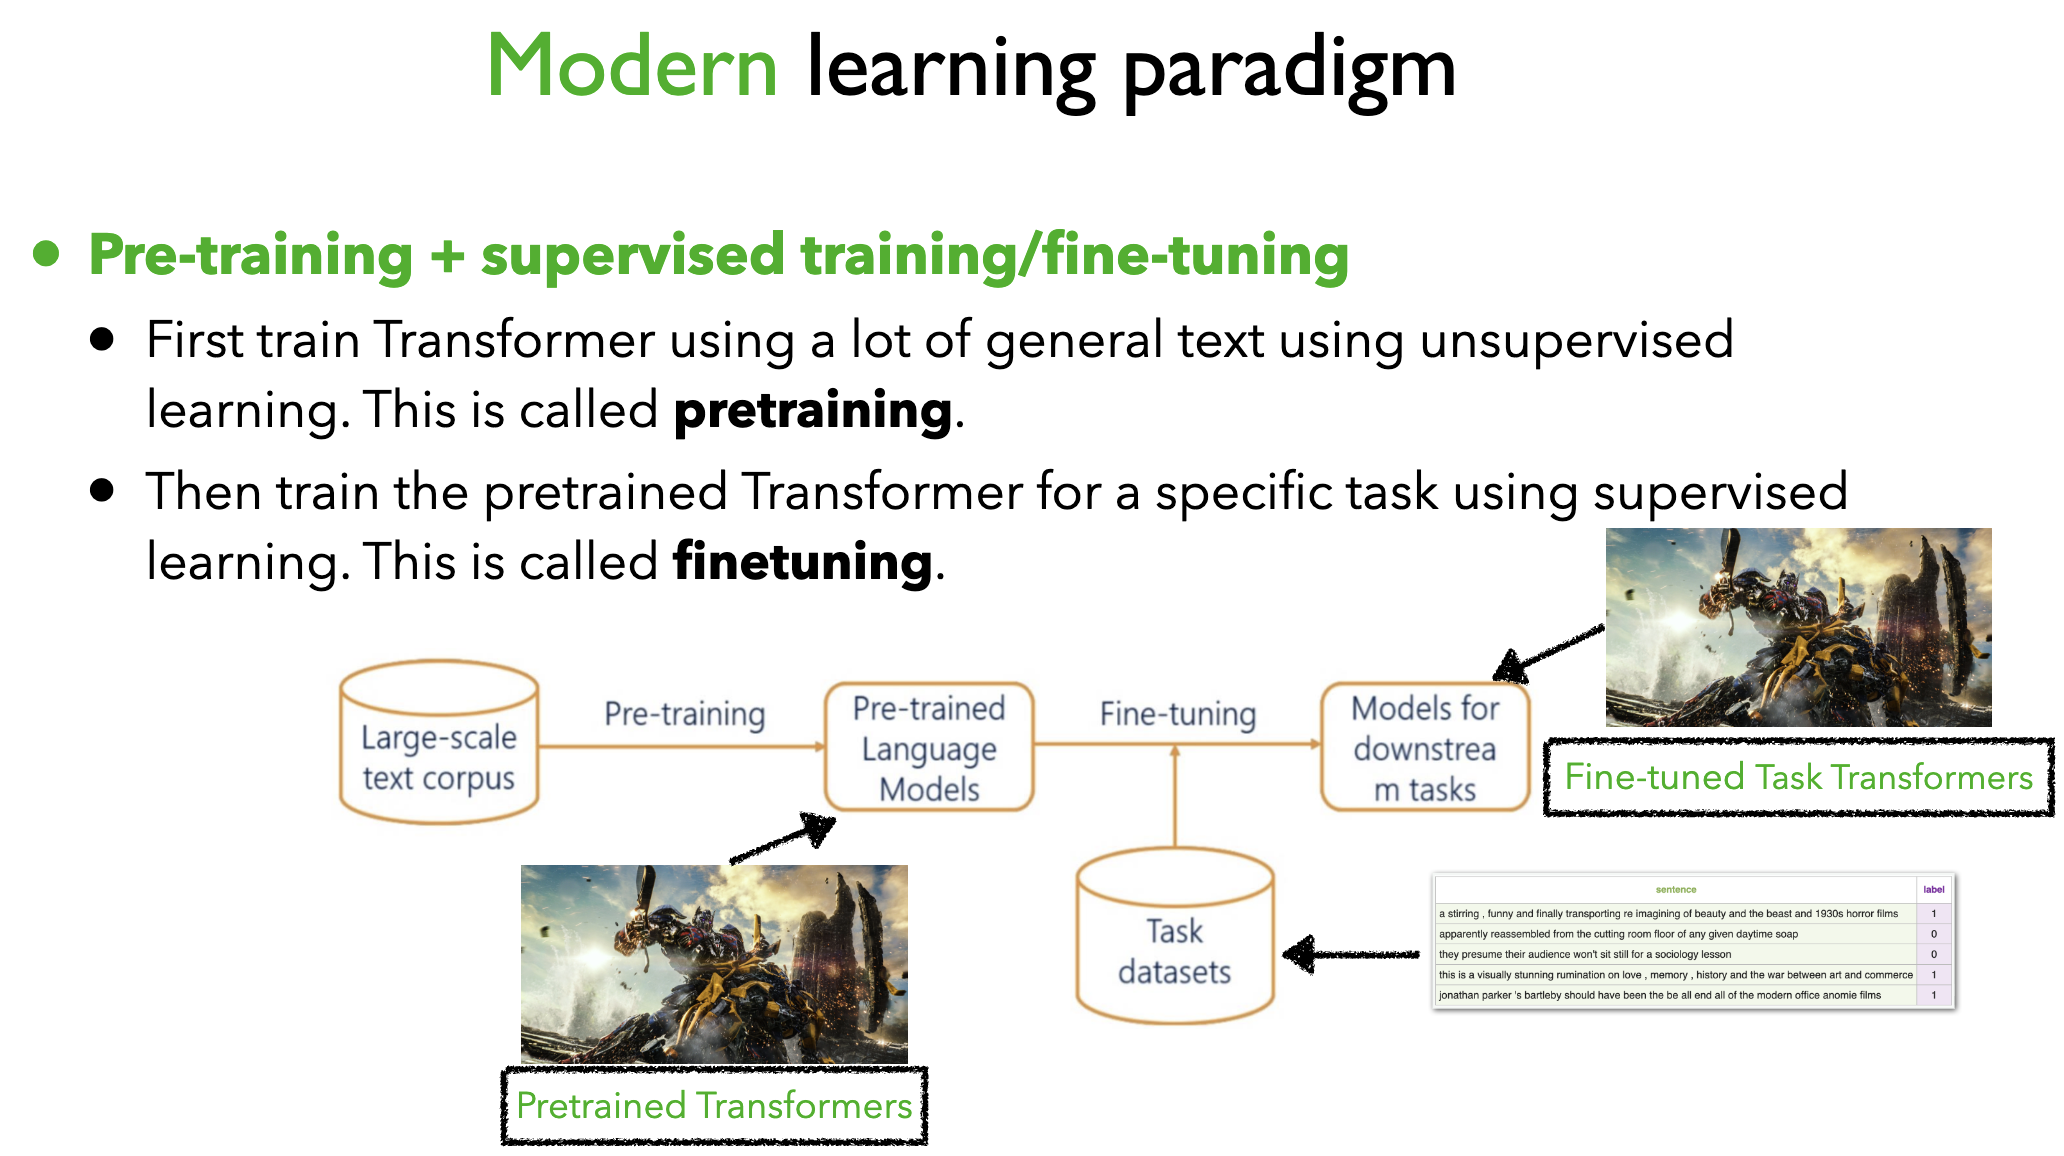

# Evolution tree of pretrained LMs
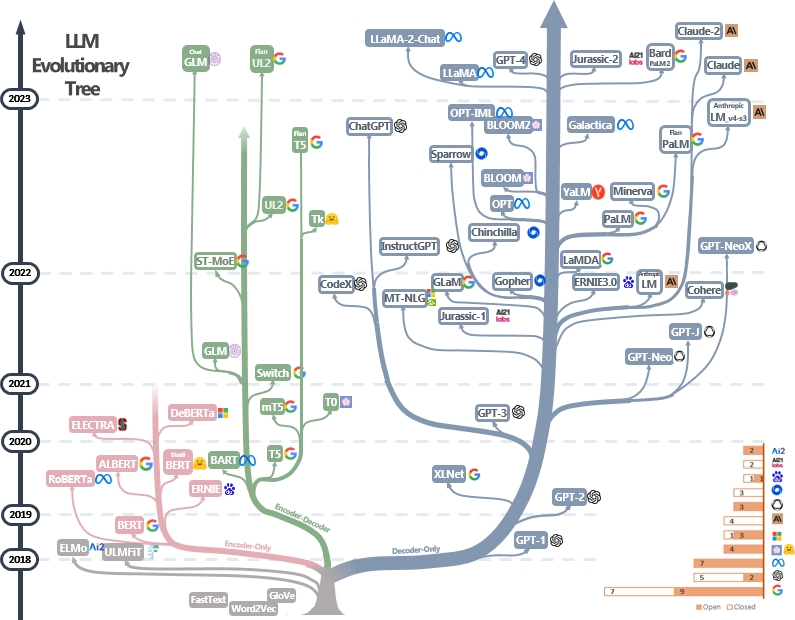



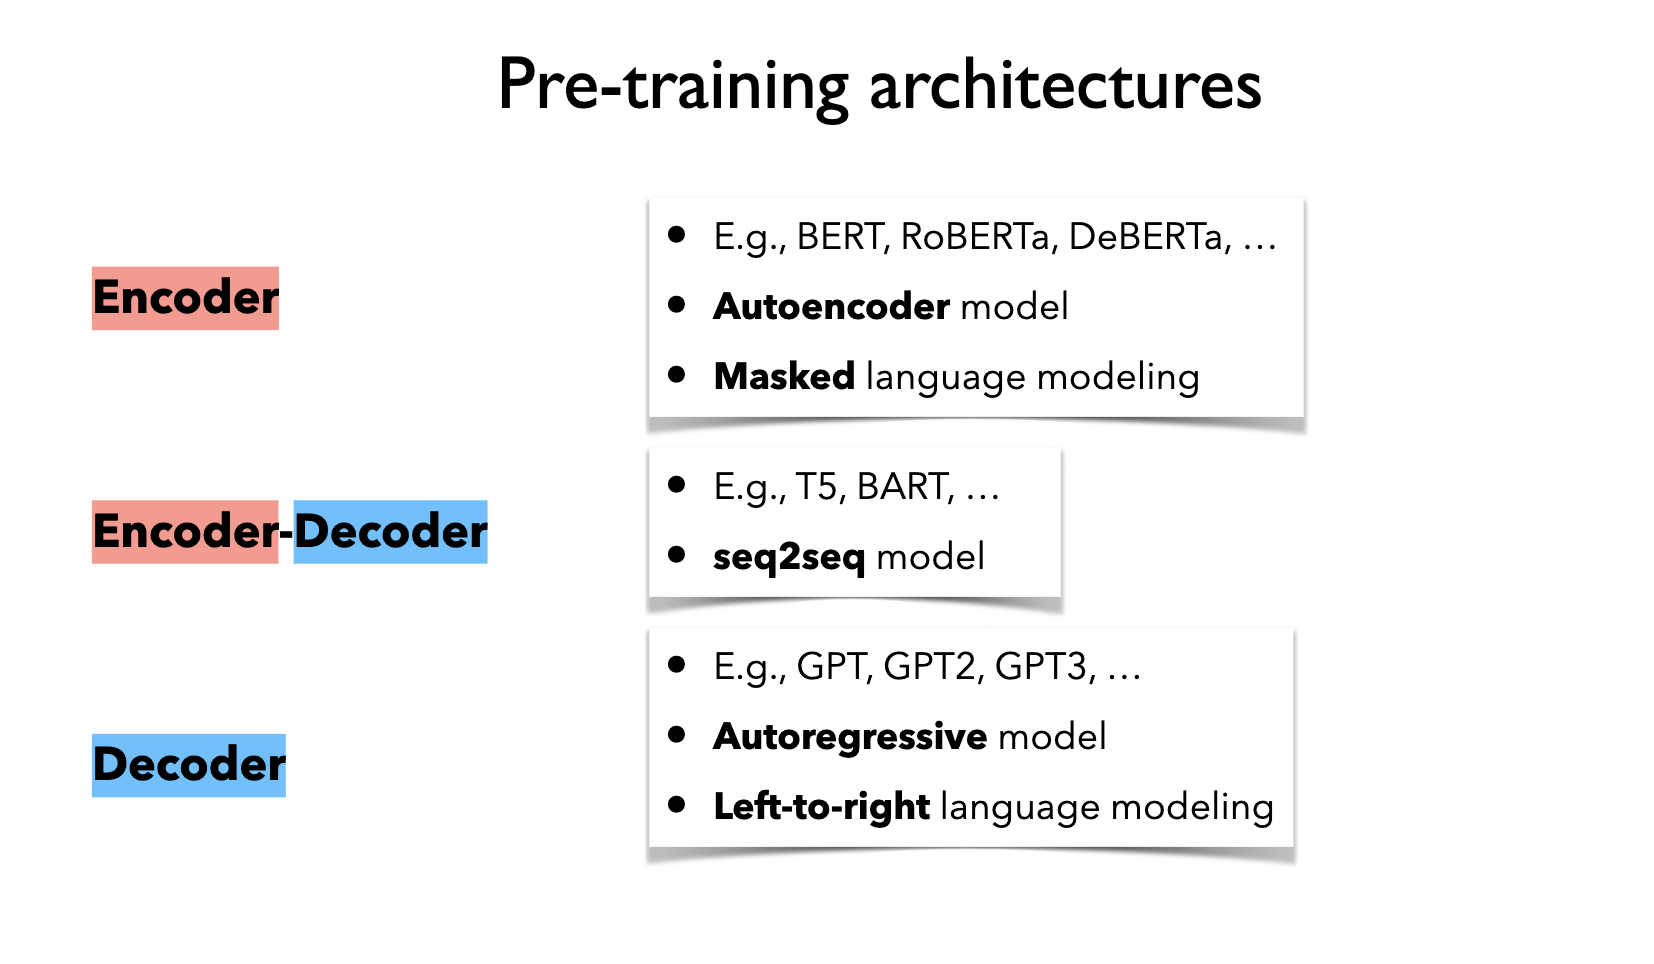



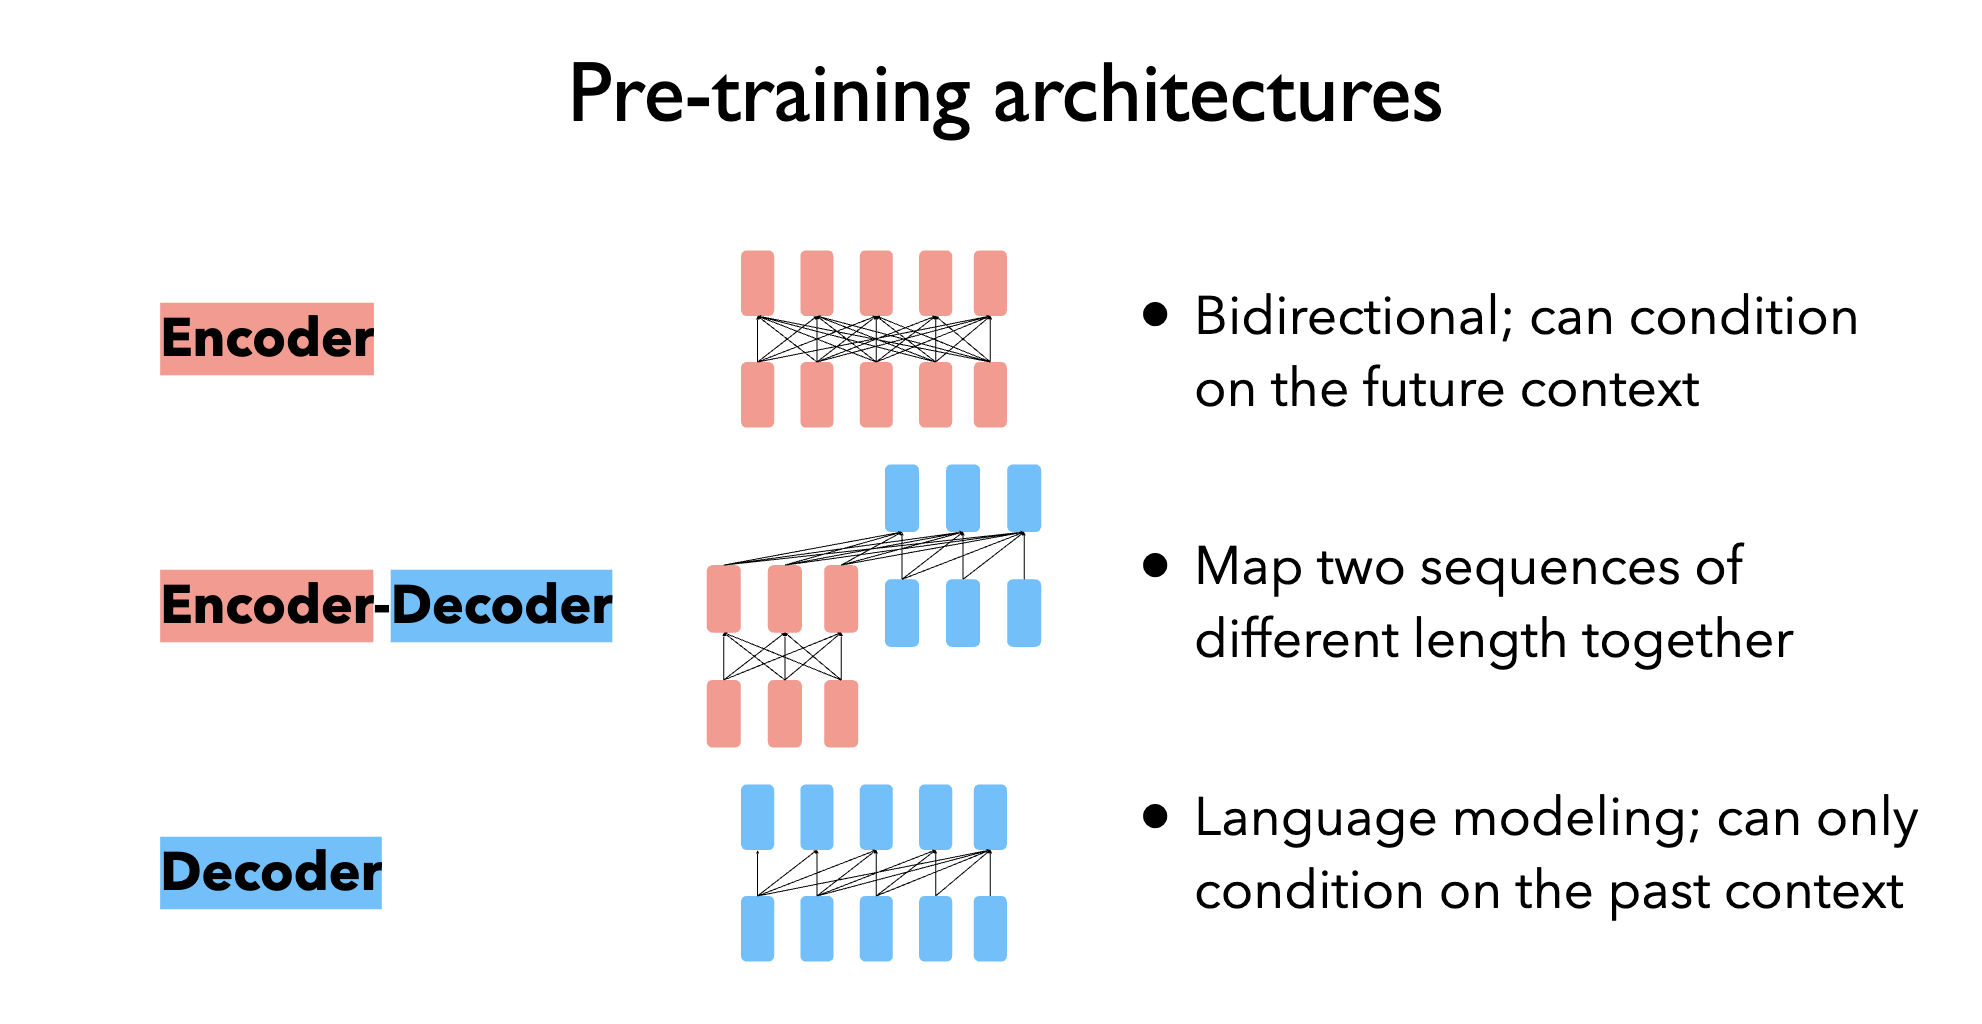

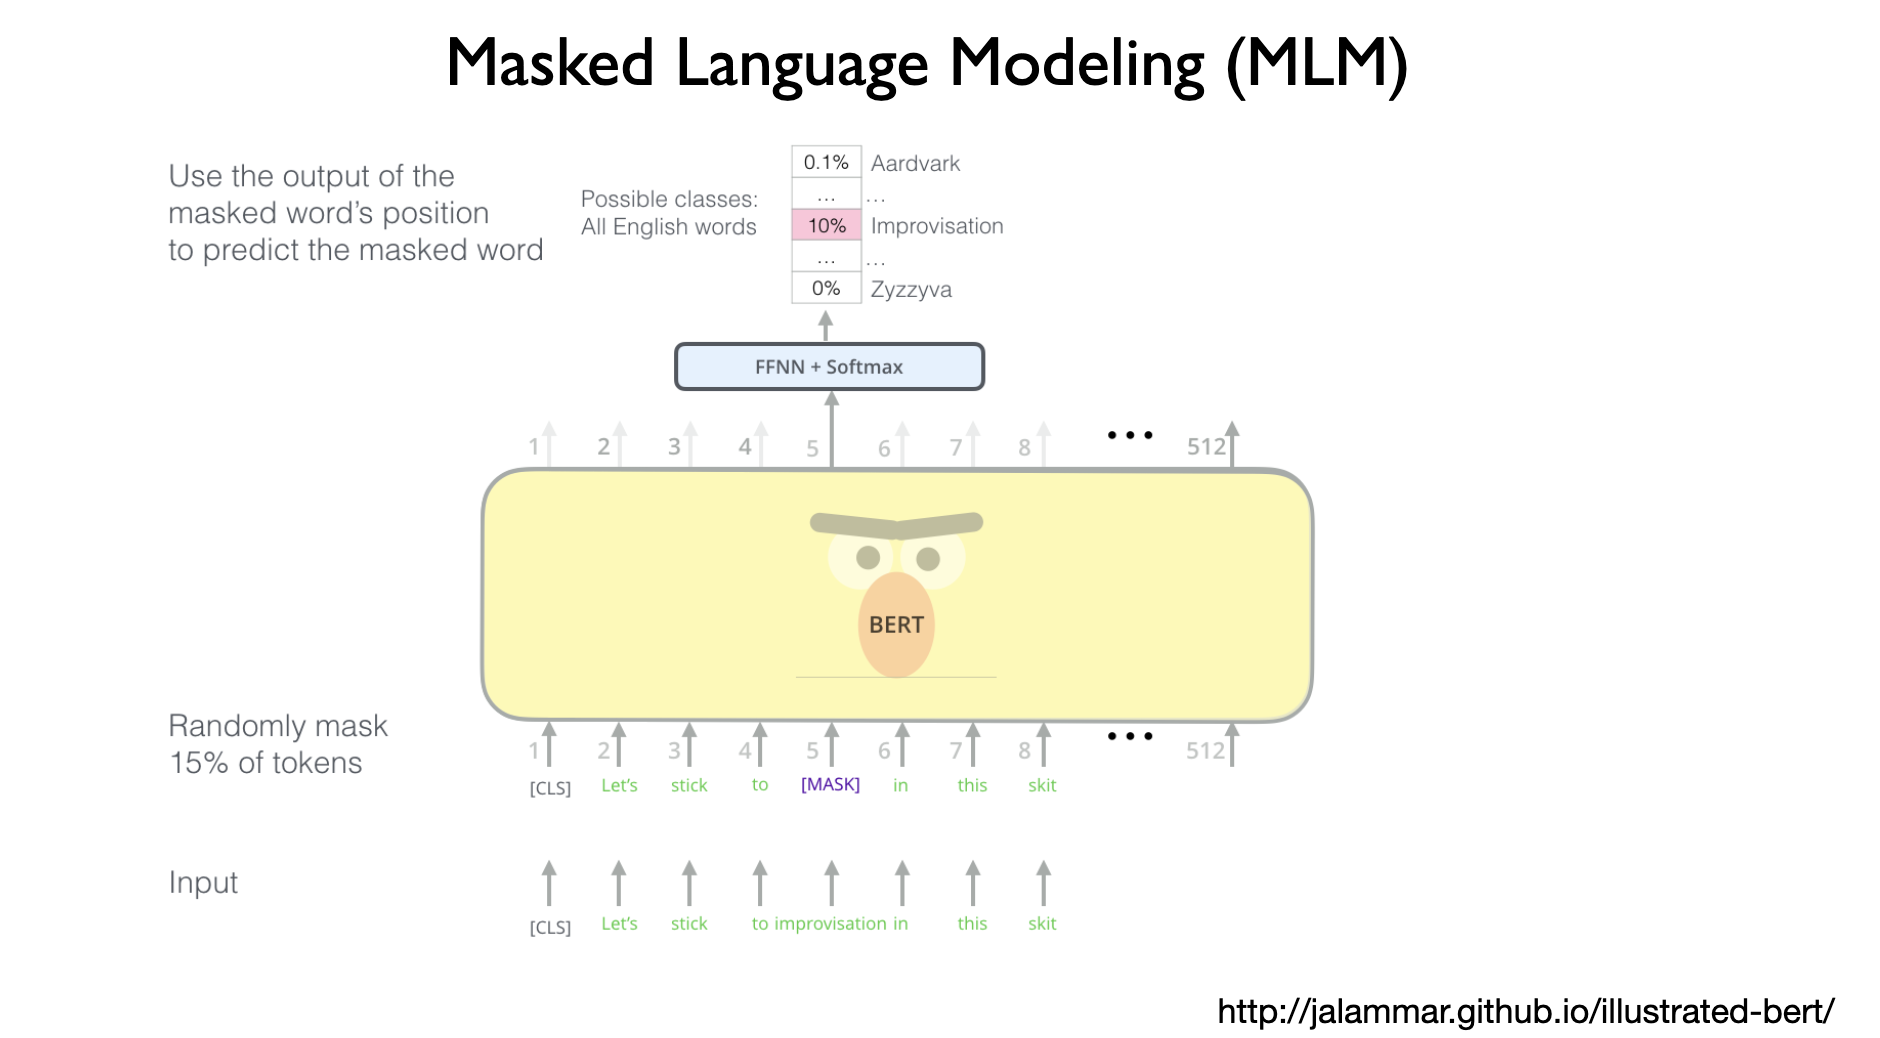

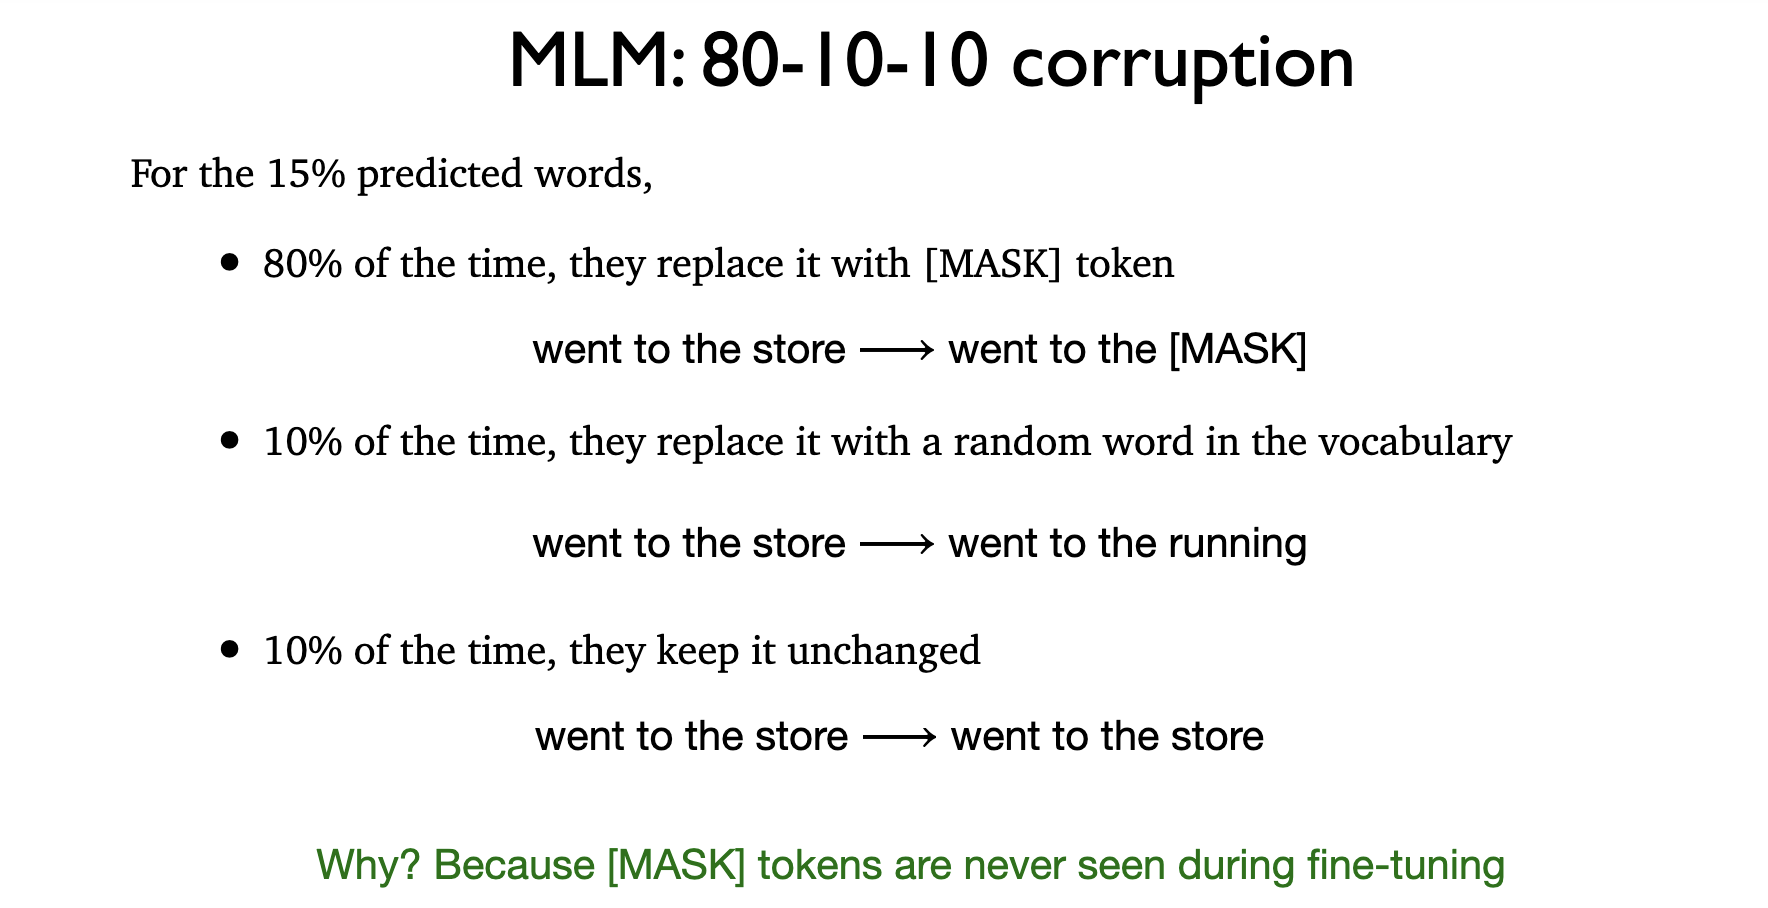

# Masked Language Modeling: BERT (Encoder-only)

In [1]:
# Imports the built-in 'random' library, used for random operations.
# In the BART script, this is used to randomly select which word spans to corrupt.
import random

# Imports the built-in 'warnings' library, which is used to control how warning messages
# (e.g., deprecation notices from libraries) are displayed.
import warnings

# Imports the 'load_dataset' function from the Hugging Face 'datasets' library.
# This is the primary function for downloading and loading datasets like 'wikitext-2' or 'imdb'.
from datasets import load_dataset

# This is the main import block from the 'transformers' library.
from transformers import (

    # --- BERT Components (for MLM) ---

    # BertConfig: The "blueprint" class for a BERT model. It defines the architecture,
    # such as the number of layers, hidden size, and number of attention heads.
    BertConfig,

    # BertTokenizerFast: The "fast" (Rust-based) tokenizer for BERT.
    # It converts text into token IDs using the WordPiece vocabulary.
    BertTokenizerFast,

    # BertForMaskedLM: The BERT model architecture with the "Masked Language Model"
    # head on top. This is the model used for MLM pre-training (predicting [MASK] tokens).
    BertForMaskedLM,

    # --- BART Components (for Denoising) ---

    # BartConfig: The "blueprint" class for a BART model, which defines the
    # Encoder-Decoder architecture.
    BartConfig,

    # BartTokenizerFast: The "fast" (Rust-based) tokenizer for BART.
    BartTokenizerFast,

    # BartForConditionalGeneration: The BART model architecture (Encoder-Decoder)
    # used for any sequence-to-sequence task, including its Denoising pre-training,
    # as well as fine-tuning for summarization or translation.
    BartForConditionalGeneration,

    # --- CLM (GPT-style) Components ---

    # AutoConfig: A generic class that can automatically load the correct
    # configuration (blueprint) from a model's name (e.g., "gpt2").
    AutoConfig,

    # AutoTokenizer: A generic class that can automatically load the correct
    # tokenizer from a model's name.
    AutoTokenizer,

    # AutoModelForCausalLM: A generic class that loads any Decoder-only model
    # (like GPT-2) designed for Causal Language Modeling (next-word prediction).
    AutoModelForCausalLM,

    # --- Data Collator Components ---

    # DataCollatorForLanguageModeling: A helper class that creates batches for
    # language modeling. It's smart: if mlm=True, it creates [MASK] tokens (for BERT).
    # If mlm=False, it sets up batches for next-word prediction (for GPT-2).
    DataCollatorForLanguageModeling,

    # DataCollatorForSeq2Seq: A helper class that creates batches for sequence-to-sequence
    # models (like BART). It independently pads the 'input_ids' (corrupted text)
    # and the 'labels' (clean text).
    DataCollatorForSeq2Seq,

    # --- Training Components ---

    # Trainer: A powerful class that handles the entire training and evaluation loop.
    # It abstracts away all the manual PyTorch code for optimization, logging, and saving.
    Trainer,

    # TrainingArguments: A class that holds all the training hyperparameters,
    # like learning rate, number of epochs, batch size, and where to save the model.
    TrainingArguments
)

# This line tells the 'warnings' library to not print any warning messages to the console.
# It's used to keep the output clean, hiding non-critical library warnings.
warnings.filterwarnings("ignore")

In [2]:
# -----------------------
# Pretraining functions
# -----------------------

# Defines a function to encapsulate the BERT (MLM) pre-training process.
def pretrain_bert():

    print("\nStarting BERT (Masked Language Modeling) pre-training...\n")

    # Load tokenizer for BERT, which knows BERT's WordPiece vocabulary and tokenization rules.
    tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

    # Creates a configuration "blueprint" for a *new* BERT model from scratch.
    config = BertConfig(
        # Sets the model's vocabulary size to match the tokenizer's.
        vocab_size=tokenizer.vocab_size,
        # Defines a small model architecture for this demo (default is 768).
        hidden_size=256, num_hidden_layers=4,
        # Sets the number of attention heads (default is 12) and feed-forward layer size.
        num_attention_heads=4, intermediate_size=1024
    )
    # Initializes a new BERT model (with random weights) designed for Masked LM,
    # based on the small 'config' blueprint.
    model = BertForMaskedLM(config)

    print(f"Model Parameters: {model.num_parameters():,}")

    # Loads the 'wikitext-2-raw-v1' dataset.
    # 'split="train[:1%]"' uses only the first 1% of the training data.
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:1%]")

    # Defines a function to tokenize the text data.
    def tokenize_fn(examples):
        # Runs the tokenizer on a batch of texts.
        # 'truncation=True' cuts long texts, 'padding="max_length"' adds padding to short texts.
        # 'max_length=128' sets a uniform length for all sequences.
        return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

    # Applies the 'tokenize_fn' to the entire dataset.
    # 'batched=True' processes texts in batches (faster).
    # 'num_proc=4' uses 4 CPU cores for parallel processing.
    # 'remove_columns=["text"]' deletes the original raw text column after tokenization.
    tokenized = dataset.map(tokenize_fn, batched=True, num_proc=4, remove_columns=["text"])

    # Creates the data collator. This is a critical step for MLM.
    # 'mlm=True' tells the collator to automatically create the [MASK] tokens.
    # 'mlm_probability=0.15' sets the chance of any token being masked to 15%.
    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)

    # Defines the training hyperparameters.
    args = TrainingArguments(
        # Specifies the directory to save model checkpoints.
        output_dir="./results_bert_mlm", num_train_epochs=5,
        # Sets the batch size (16) and enables 'fp16' (mixed-precision) for faster GPU training.
        per_device_train_batch_size=16, fp16=True, overwrite_output_dir=True,
        # Logs the training loss every 200 steps and disables external logging (like wandb).
        logging_steps=200, report_to="none"
    )

    # Initializes the Trainer object.
    # This class bundles the model, arguments, data collator, and dataset together.
    trainer = Trainer(model=model, args=args, data_collator=data_collator, train_dataset=tokenized)

    # Starts the actual pre-training process.
    trainer.train()

    # Saves the final trained model weights and config to the specified directory.
    trainer.save_model("./results_bert_mlm/final_model")
    # Saves the tokenizer files to the same directory, so it's bundled with the model.
    tokenizer.save_pretrained("./results_bert_mlm/final_model")
    # Prints a final message indicating the process is complete.
    print("\nBERT pre-training complete.\n")

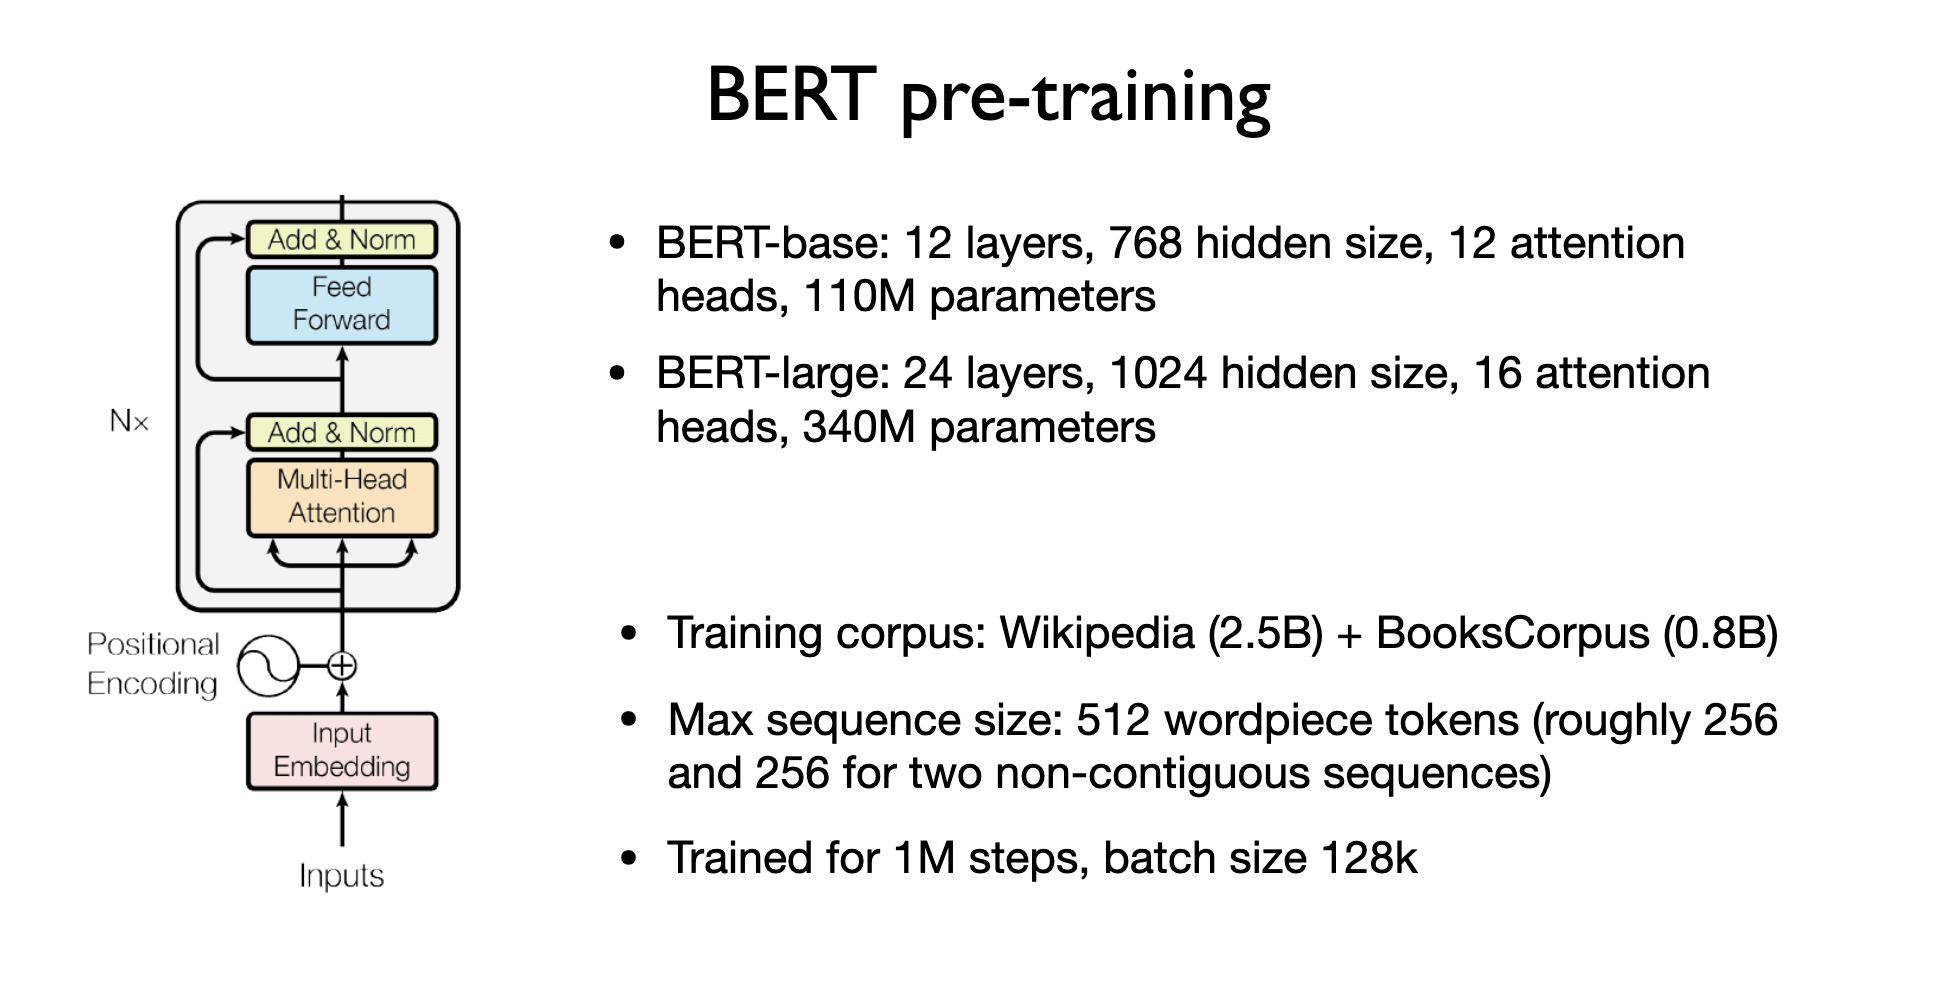

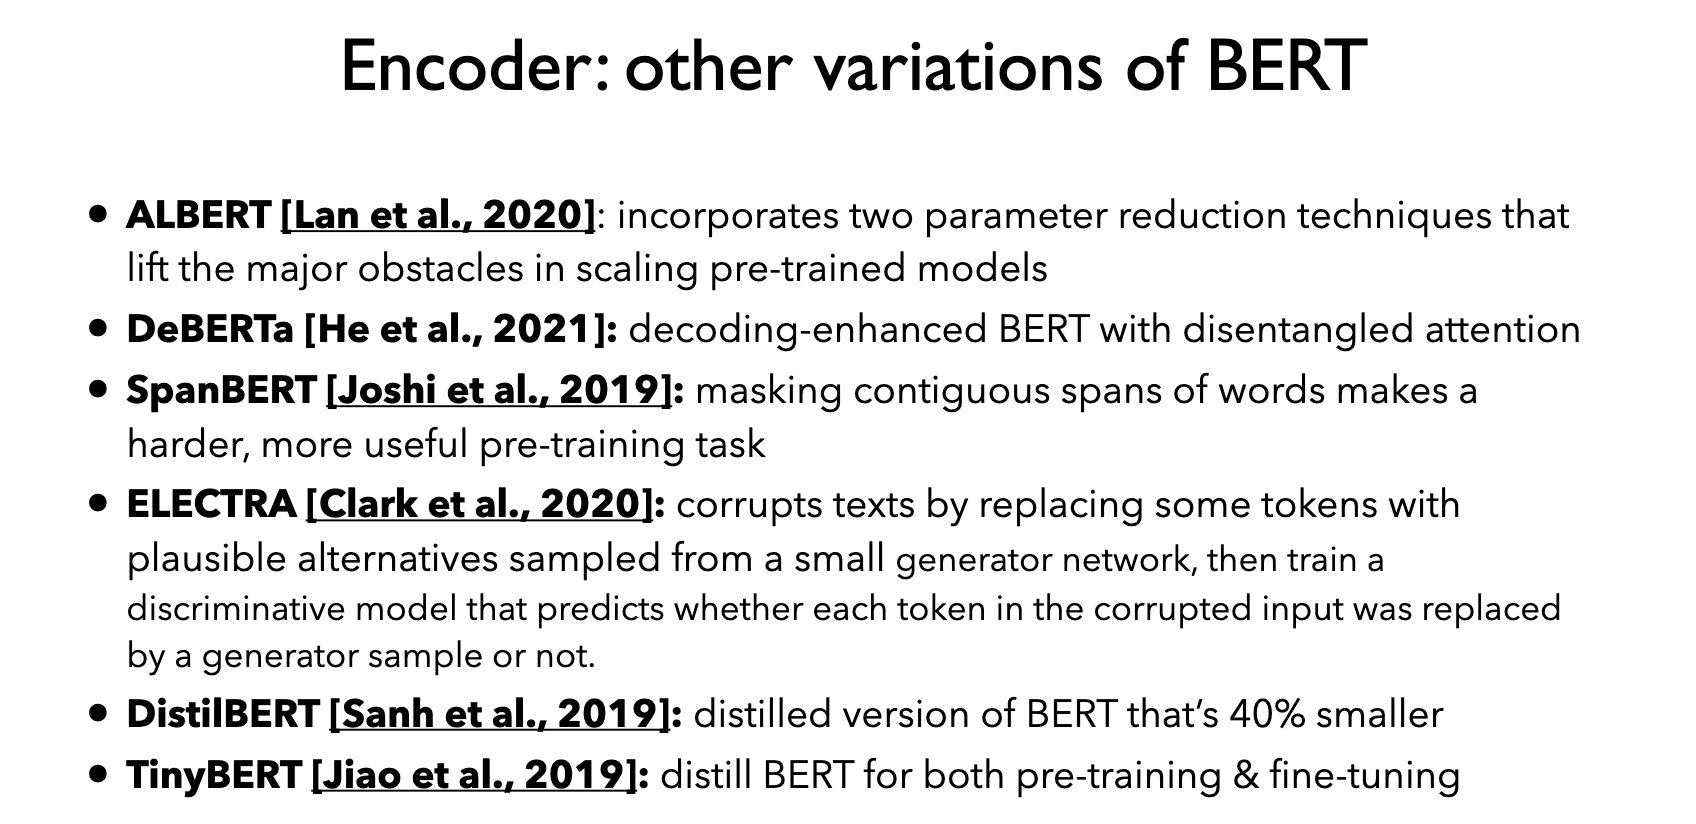

# Denoising Autoencoding: BART / T5 (Encoder-Decoder)

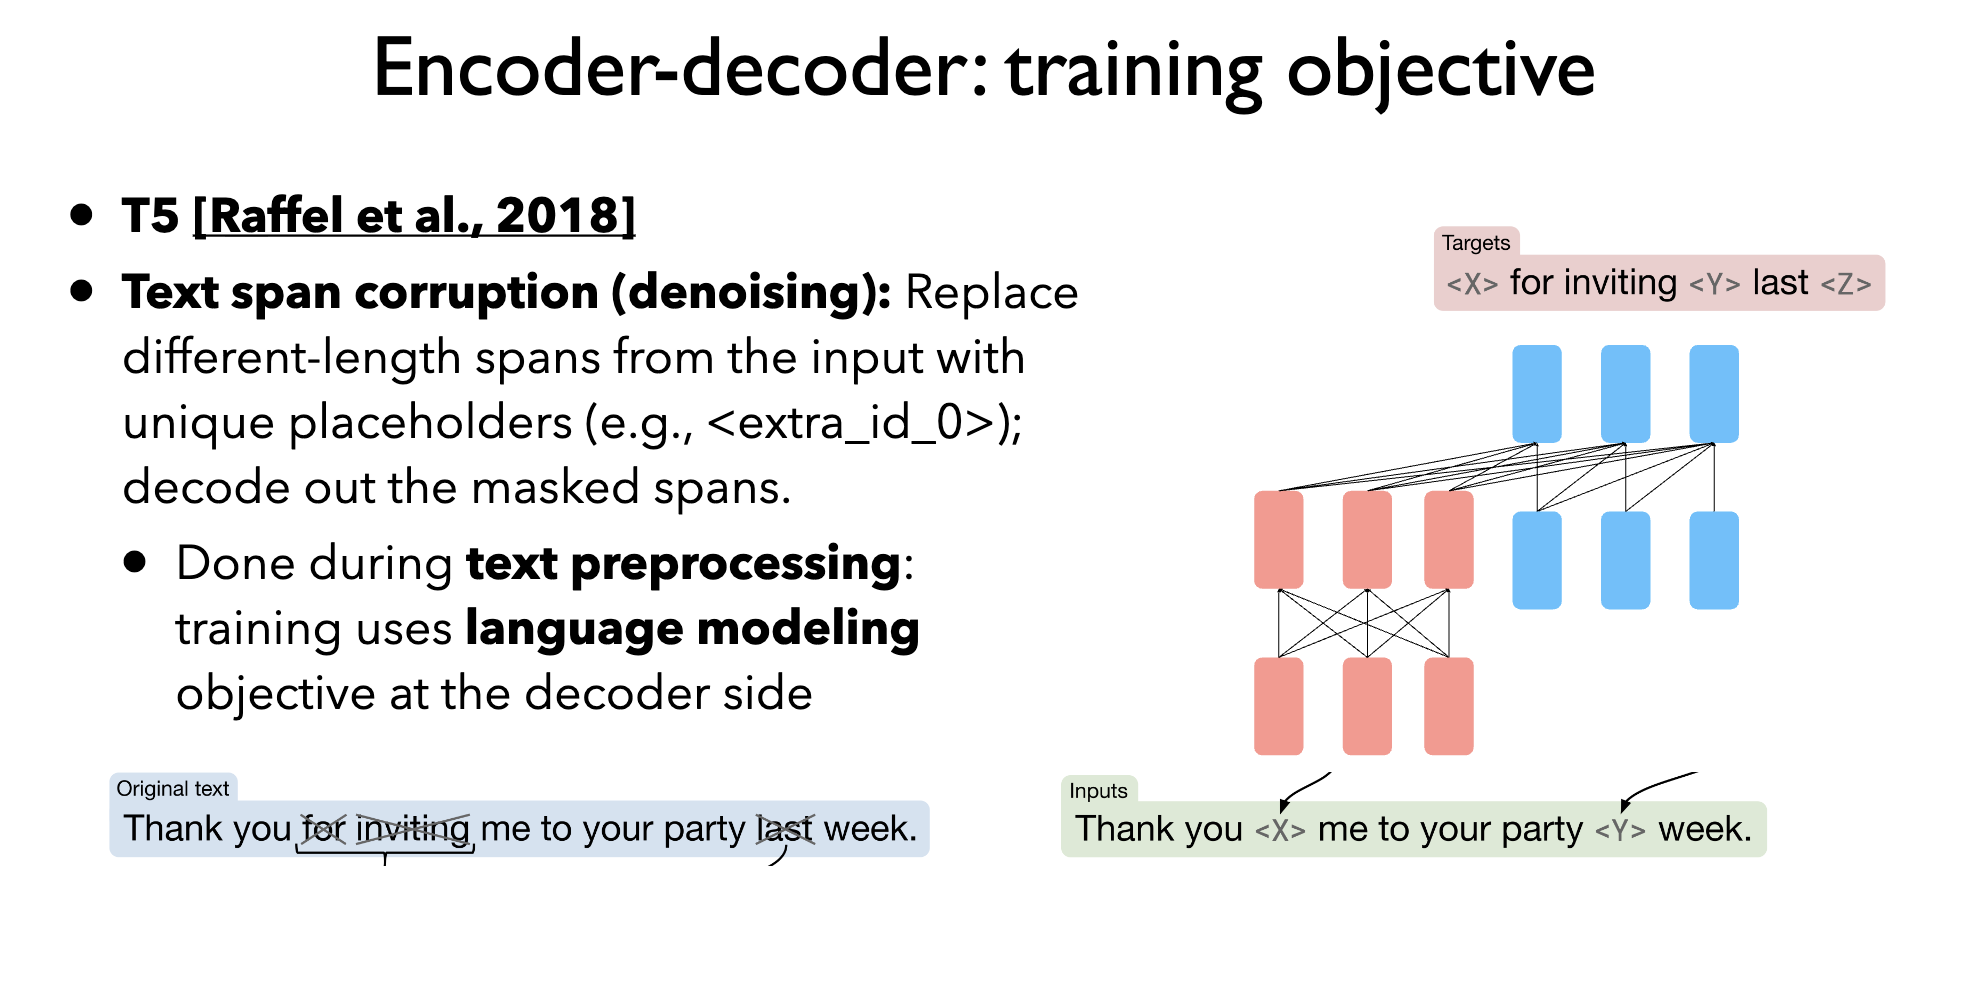

In [1]:

# ------------------------------
# BART corruption function
# ------------------------------

# Defines a function to "corrupt" a piece of text for BART's denoising pre-training.
# It takes the raw text, the tokenizer (to access tokenizer.mask_token),
# the probability of masking, and the length of each mask span.
def corrupt_text(text, tokenizer, mask_prob=0.15, span_length=3):
    """Simple corruption for BART's text infilling objective."""

    # Splits the input text into a list of individual words.
    words = text.split()

    # Gets the total number of words in the list.
    n_words = len(words)

    # If the text is shorter than the span length, corruption is impossible,
    # so it returns the original text.
    if n_words < span_length:
        return text

    # Calculates the number of spans to mask.
    # It takes the smaller of (total words * mask_prob) or a number that ensures
    # at least one span is masked (max(1, ...)) if possible.
    n_to_mask = min(int(n_words * mask_prob), max(1, n_words // span_length))

    # Randomly selects 'n_to_mask' unique starting indices for the spans.
    # The range ensures that a full 'span_length' can be taken from the chosen index.
    masked_indices = random.sample(range(n_words - span_length + 1), n_to_mask)

    # Initializes an empty list to build the new, corrupted list of words.
    masked_words = []

    # Initializes a counter 'i' to loop through the original word list.
    i = 0

    # Loops through the words one by one.
    while i < n_words:
        # Checks if the current word index 'i' is one of the randomly chosen start points.
        if i in masked_indices:
            # If it is, appends a *single* mask token (e.g., "<mask>") to the new list.
            masked_words.append(tokenizer.mask_token)

            # Jumps the counter forward by 'span_length', effectively deleting
            # the 'span_length' words from the original text.
            i += span_length
        else:
            # If 'i' is not a mask starting point, just append the original word.
            masked_words.append(words[i])

            # Increment the counter by one to check the next word.
            i += 1

    # Joins the new list of words (with <mask> tokens) back into a single string.
    return " ".join(masked_words)




# Defines a function to encapsulate the BART (Denoising) pre-training process.
def pretrain_bart():
    # Prints a status message to the console.
    print("\nStarting BART (Denoising) pre-training...\n")

    # Loads the "fast" (Rust-based) tokenizer for BART, which includes its
    # specific vocabulary and tokenization rules.
    tokenizer = BartTokenizerFast.from_pretrained("facebook/bart-base")

    # Prints the specific mask token (e.g., "<mask>") used by this tokenizer.
    # This is needed by the 'corrupt_text' function.
    print(tokenizer.mask_token)

    # Creates a configuration "blueprint" for a *new* BART model from scratch.
    config = BartConfig(
        # Sets the model's vocabulary size to match the tokenizer's.
        # 'd_model' is the hidden size (256 is small for a fast demo; base is 768).
        vocab_size=tokenizer.vocab_size, d_model=256,

        # Specifies a small model with 4 encoder layers and 4 decoder layers (base is 6).
        encoder_layers=4, decoder_layers=4,

        # Sets a small number of attention heads (base is 12).
        encoder_attention_heads=4, decoder_attention_heads=4,

        # Sets the intermediate feed-forward network size (the "expansion" size) inside each block.
        encoder_ffn_dim=1024, decoder_ffn_dim=1024,
    )
    # Initializes a new BART Encoder-Decoder model (with random weights) based on the small 'config'.
    model = BartForConditionalGeneration(config)

    # Prints the total number of trainable parameters in the newly created model.
    print(f"Model Parameters: {model.num_parameters():,}")

    # Loads the 'wikitext-2' dataset, using only the first 15% of the training split
    # to make the pre-training demo run quickly.
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:1%]")

    # Defines the main preprocessing function that will be applied to the dataset.
    def preprocess_fn(examples):
        # Gets the list of clean, original text sentences from the current batch.
        original = examples["text"]

        # Creates a new list of "damaged" sentences by running each clean sentence
        # through the 'corrupt_text' function defined earlier.
        corrupted = [corrupt_text(t, tokenizer) for t in original]

        # Tokenizes the **corrupted** text. This will be the input for the model's ENCODER.
        model_inputs = tokenizer(corrupted, truncation=True, padding="max_length", max_length=128)

        # 'as_target_tokenizer()' is a context manager that ensures the labels (the decoder's target) are tokenized correctly (e.g., handling special tokens).
        with tokenizer.as_target_tokenizer():
            # Tokenizes the **original** (clean) text. This will be the target for the model's DECODER.
            labels = tokenizer(original, truncation=True, padding="max_length", max_length=128)

        # Adds the tokenized clean text (the 'labels') to the main input dictionary.
        # The model will use this for calculating the loss.
        model_inputs["labels"] = labels["input_ids"]

        # Returns the processed dictionary, which now contains 'input_ids' (corrupted)
        # and 'labels' (clean).
        return model_inputs

    # Applies the 'preprocess_fn' to the entire dataset.
    # 'batched=True' processes texts in batches (faster).
    # 'num_proc=4' uses 4 CPU cores for parallel processing.
    # 'remove_columns=["text"]' deletes the original raw text column as it's no longer needed.
    tokenized = dataset.map(preprocess_fn, batched=True, num_proc=4, remove_columns=["text"])

    # Initializes the data collator specifically designed for Sequence-to-Sequence tasks.
    # This collator will intelligently pad the 'input_ids' (corrupted) and 'labels' (clean) batches,
    # and also create the 'decoder_input_ids' automatically.
    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

    # Defines the training hyperparameters.
    args = TrainingArguments(
        # Sets the directory to save model checkpoints.
        output_dir="./results_bart_denoising", num_train_epochs=5,

        # Sets batch size (16), enables 'fp16' (mixed-precision) for faster GPU training,
        # and allows overwriting any previous results in the output directory.
        per_device_train_batch_size=16, fp16=True, overwrite_output_dir=True,

        # Logs the training loss every 200 steps and disables external reporting (like wandb).
        logging_steps=200, report_to="none"
    )

    # Initializes the Trainer object, bundling the model, args, collator, and dataset.
    trainer = Trainer(model=model, args=args, data_collator=data_collator, train_dataset=tokenized)

    # Starts the actual pre-training process.
    trainer.train()

    # Saves the final trained model weights and config to the specified directory.
    trainer.save_model("./results_bart_denoising/final_model")

    # Saves the tokenizer files to the same directory, bundling it with the model.
    tokenizer.save_pretrained("./results_bart_denoising/final_model")

    # Prints a final message indicating the process is complete.
    print("\nBART pre-training complete.\n")

# Causal Language Modeling: GPT (Decoder-only)

---



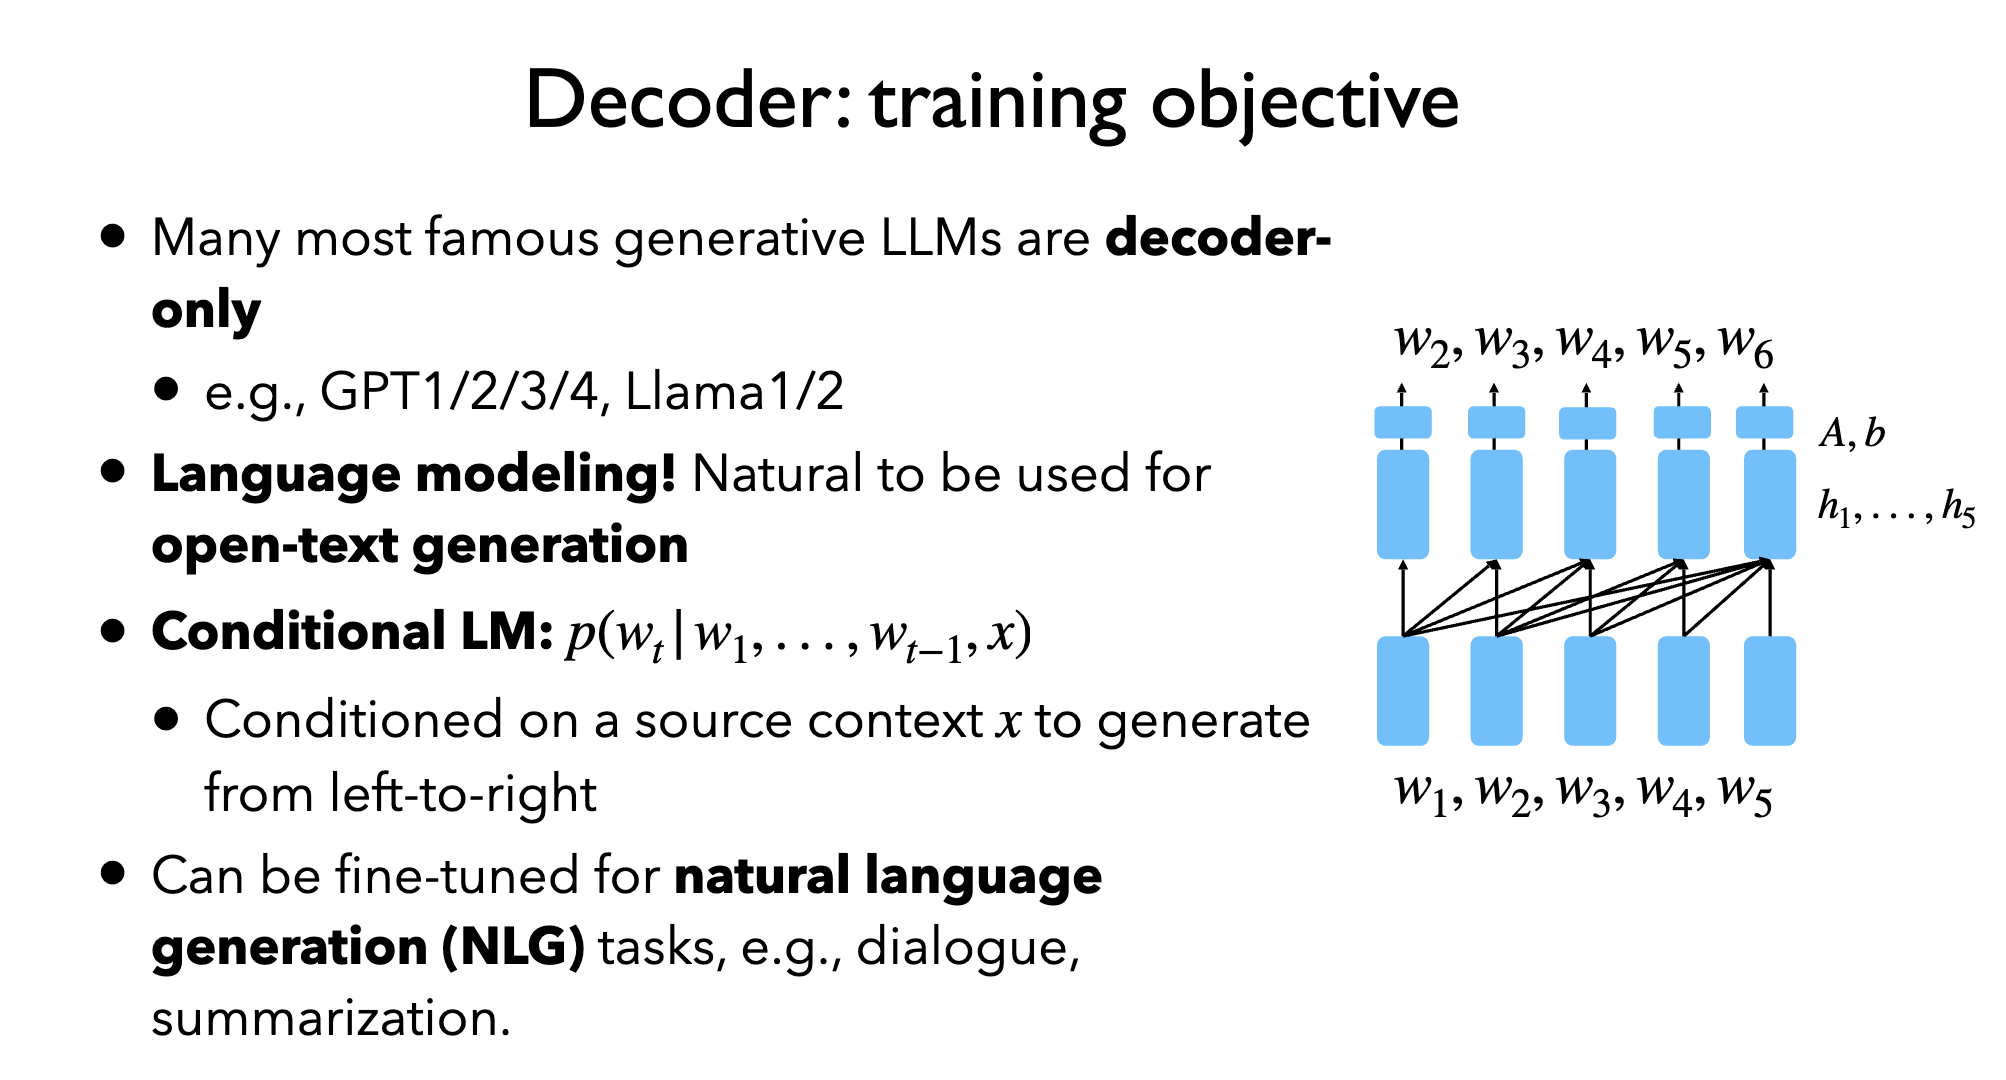

In [5]:
# Defines a function to encapsulate the GPT-style (CLM) pre-training process.
def pretrain_gpt():
    # Prints a status message to the console.
    print("\nStarting GPT-style (Causal Language Modeling) pre-training...\n")

    # Loads the "fast" (Rust-based) tokenizer associated with "gpt2".
    # 'AutoTokenizer' automatically selects the correct tokenizer class (GPT2TokenizerFast).
    tokenizer = AutoTokenizer.from_pretrained("gpt2")

    # GPT-2 models don't have a specific [PAD] token by default.
    # This line sets the padding token to be the end-of-sentence token ("<|endoftext|>").
    # This is a common practice for CLM models when padding is needed.
    tokenizer.pad_token = tokenizer.eos_token

    # Loads the configuration "blueprint" from the "gpt2" model.
    config = AutoConfig.from_pretrained(
        "gpt2",
        # Overrides specific parameters to create a *small* model for this demo:
        vocab_size=len(tokenizer), # Ensures the model's vocab size matches the tokenizer's.
        n_layer=4,                 # Sets 4 layers (default is 12).
        n_head=4,                  # Sets 4 attention heads (default is 12).
        n_embd=256                 # Sets the hidden size/embedding dimension to 256 (default is 768).
    )
    # Initializes a new CLM model (with random weights) from the small 'config' blueprint.
    # 'AutoModelForCausalLM' automatically selects 'GPT2LMHeadModel'.
    model = AutoModelForCausalLM.from_config(config)

    # Prints the total number of trainable parameters in the newly created small model.
    print(f"Model Parameters: {model.num_parameters():,}")

    # Loads the 'wikitext-2' dataset, using only the first 15% of the training split
    # to make the pre-training demo run quickly.
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:1%]")

    # Defines a function to tokenize the text data.
    def tokenize_fn(examples):
        # Runs the tokenizer on a batch of texts.
        # 'truncation=True' cuts long texts, 'padding="max_length"' adds padding to short texts.
        # 'max_length=128' sets a uniform length for all sequences.
        return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

    # Applies the 'tokenize_fn' to the entire dataset.
    # 'batched=True' processes texts in batches (faster).
    # 'num_proc=4' uses 4 CPU cores for parallel processing.
    # 'remove_columns=["text"]' deletes the original raw text column after tokenization.
    tokenized = dataset.map(tokenize_fn, batched=True, num_proc=4, remove_columns=["text"])

    # Creates the data collator.
    # 'mlm=False' is the critical part for CLM. It tells the collator *not* to mask tokens.
    # Instead, the collator will batch the inputs, and the 'AutoModelForCausalLM' model
    # will automatically shift the inputs/labels to create the next-word prediction task.
    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

    # Defines the training hyperparameters.
    args = TrainingArguments(
        # Specifies the directory to save model checkpoints.
        output_dir="./results_clm", num_train_epochs=5,

        # Sets batch size (16), enables 'fp16' (mixed-precision) for faster GPU training,
        # and allows overwriting any previous results in the output directory.
        per_device_train_batch_size=16, fp16=True, overwrite_output_dir=True,

        # Logs the training loss every 200 steps and disables external reporting (like wandb).
        logging_steps=200, report_to="none"
    )

    # Initializes the Trainer object, bundling the model, args, collator, and dataset.
    trainer = Trainer(model=model, args=args, data_collator=data_collator, train_dataset=tokenized)

    # Starts the actual pre-training process.
    trainer.train()

    # Saves the final trained model weights and config to the specified directory.
    trainer.save_model("./results_clm/final_model")

    # Saves the tokenizer files to the same directory, bundling it with the model.
    tokenizer.save_pretrained("./results_clm/final_model")

    # Prints a final message indicating the process is complete.
    print("\nGPT-style pre-training complete.\n")

In [6]:
pretrain_bert()





Starting BERT (Masked Language Modeling) pre-training...



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/5508 [00:00<?, ? examples/s]

Step,Training Loss
200,8.974600
400,7.542000
600,7.224600
800,7.079300
1000,7.062000
1200,7.069200
1400,7.062500
1600,6.972200



BERT pre-training complete.



In [7]:
pretrain_bart()



Starting BART (Denoising) pre-training...



vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

<mask>
Model Parameters: 20,766,976


Map (num_proc=4):   0%|          | 0/5508 [00:00<?, ? examples/s]

Step,Training Loss
200,9.076500
400,6.185100
600,4.278300
800,3.112400
1000,2.622300
1200,2.481200
1400,2.437700
1600,2.380300



BART pre-training complete.



In [8]:
pretrain_gpt()


Starting GPT-style (Causal Language Modeling) pre-training...



tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Model Parameters: 16,287,488


Map (num_proc=4):   0%|          | 0/5508 [00:00<?, ? examples/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
200,9.040800
400,7.392000
600,6.897200
800,6.715100
1000,6.630000
1200,6.550900
1400,6.549800
1600,6.482200



GPT-style pre-training complete.



In [ ]:
from transformers import pipeline

def use_pretrained_model(model_type: str, model_dir: str, text: str):
    """
    Use a pretrained model for inference (BERT, BART, or GPT).
    Args:
        model_type (str): 'bert', 'bart', or 'gpt'
        model_dir (str): path to the fine-tuned or pretrained model folder
        text (str): input text
    """

    print(f"\nLoading model from {model_dir} for {model_type.upper()} inference...\n")

    if model_type == "bert":
        # --- Masked Token Prediction ---
        unmasker = pipeline("fill-mask", model=model_dir, tokenizer=model_dir)
        print(f"Input: {text}")
        predictions = unmasker(text)
        print("\nTop predictions:")
        for pred in predictions:
            print(f"{pred['sequence']} (prob: {pred['score']:.4f})")

    elif model_type == "bart":
        # --- Denoising (Text Reconstruction) ---
        generator = pipeline("text2text-generation", model=model_dir, tokenizer=model_dir)
        print(f"Corrupted input: {text}")
        output = generator(text, max_length=100, num_beams=4)
        print(f"\nReconstructed text:\n{output[0]['generated_text']}")

    elif model_type == "gpt":
        # --- Text Continuation ---
        generator = pipeline("text-generation", model=model_dir, tokenizer=model_dir)
        print(f"Prompt: {text}")
        outputs = generator(text, max_length=100, num_return_sequences=1)
        print(f"\nGenerated text:\n{outputs[0]['generated_text']}")

    else:
        raise ValueError("Invalid model_type. Choose from 'bert', 'bart', or 'gpt'.")


In [ ]:
use_pretrained_model("bert", "./results_bert_mlm/final_model", "The capital of France is [MASK].")


In [ ]:
use_pretrained_model("bart", "./results_bart_denoising/final_model", "The [MASK] fox jumps [MASK] the lazy dog.")


In [ ]:
use_pretrained_model("gpt", "./results_clm/final_model", "Artificial intelligence will revolutionize")


# Model Architecture and Size

| Model           | Architecture Type | Real Model Size                                | Our Demo Size                               |
| --------------- | ----------------- | ---------------------------------------------- | ------------------------------------------- |
| **BERT-base**   | Encoder-only      | 12 layers, 768 hidden, 12 heads (~110M params) | 4 layers, 256 hidden, 4 heads (~15M params) |
| **BART-base**   | Encoder–Decoder   | 6 enc + 6 dec, 768 hidden (~139M params)       | 4 enc + 4 dec, 256 hidden (~20M params)     |
| **GPT-2 small** | Decoder-only      | 12 layers, 768 hidden (~124M params)           | 4 layers, 256 hidden (~15M params)          |



Capacity is roughly 10× smaller → less learning power.

# Dataset and Scale


| Model           | Real Dataset                           | Tokens Seen | Our Demo                        |
| --------------- | -------------------------------------- | ----------- | ------------------------------- |
| **BERT-base**   | BooksCorpus + Wikipedia (~3.3B tokens) | 3.3B        | ~100K tokens (1% of WikiText-2) |
| **BART-base**   | News + Wikipedia (~160GB)              | Billions    | ~100K tokens                    |
| **GPT-2 small** | WebText (~40GB)                        | ~10B tokens | ~100K tokens                    |

It’s 10,000× smaller than real pretraining data.

<h1>Tips and Tricks for Pre-training</h1>
<p>
Pretraining language models can be a challenging and time-consuming task, but there are several tips and tricks that can help you get the best results:
<ul>
<li>Choose the right dataset: The quality and size of the dataset used for pretraining can have a significant impact on the performance of the language model. It's important to choose a dataset that is large enough and representative of the target domain.</li>
<li>Use data augmentation techniques: Data augmentation can help increase the diversity of the training data and improve the robustness of the language model. Common techniques include random deletion, shuffling, and masking of words.</li>
<li>Experiment with different architectures: There are many different architectures that can be used for pretraining language models, including Transformer-based models, LSTM-based models, and CNN-based models. Experimenting with different architectures can help you find the one that works best for your specific task.</li>
<li>Fine-tune on downstream tasks: Fine-tuning the pretrained language model on specific downstream tasks can help improve its performance and make it more useful. It's important to choose a diverse set of downstream tasks to ensure that the model is able to generalize well to new tasks.
Monitor training progress: Monitoring the training progress of the language model can help you identify issues early on and make adjustments as needed. It's important to keep track of metrics such as loss, perplexity, and accuracy during training.</li>
<li>Regularize the model: Regularization techniques such as dropout, weight decay, and early stopping can help prevent overfitting and improve the generalization ability of the language model.</li>
<li>Use a large batch size: Using a large batch size during training can help improve the efficiency of the training process and lead to better results. However, it's important to choose a batch size that is appropriate for the available hardware and memory constraints</li>
</ul>
</p>

<h1>Conclusion</h1>
<p>
In conclusion, the exploration and implementation of various pretraining techniques, such as Masked Language Modeling, Denoising, and Causal Lang Modeling, have shown that each technique can significantly impact the performance of language models on various Fine-Tuning tasks.
</p>
<p>
While each technique has its unique advantages and disadvantages, they are all important for improving language models' performance and allowing them to excel in various Fine-Tuning tasks.
</p>
<p>
In summary, pretraining techniques have revolutionized the field of Natural Language Processing and are vital for developing highly accurate and effective language models. By continuing to explore and improve these techniques, we can push the boundaries of what language models can achieve and drive new innovations in the field.
</p>


# Additional literature
If you are interested in exploring the topic of language models pretraining further following are additional useful literature:

1. "Don't Stop Pretraining: Adapt Language Models to Domains and Tasks" by Wei Yang, et al. (2020) proposes a novel approach to adapting pre-trained language models to specific domains and tasks through continued pre-training. The authors show that this approach outperforms fine-tuning on a variety of downstream tasks, including sentiment analysis, named entity recognition, and question answering.

2. "Self-training Improves Pre-training for Natural Language Understanding" by Xiaoya Li, et al. (2021) investigates the effectiveness of self-training in improving pre-training for natural language understanding. The authors propose a self-training framework that iteratively refines the pre-trained model by leveraging unlabeled data, and show that this approach can significantly improve the performance of the pre-trained model on several downstream tasks, including natural language inference and sentiment analysis.

3. "Frustratingly Simple Pretraining Alternatives to Masked Language Modeling" by Alex Wang, et al. (2021) explores simple alternatives to the popular pre-training technique of Masked Language Modeling (MLM) and evaluates their effectiveness on several downstream tasks. The authors propose and evaluate two pre-training objectives: Permutation Language Modeling (PLM), which involves predicting the order of randomly permuted words, and Sentence Order Prediction (SOP), which involves predicting the relative order of sentences in a document.
These articles highlight the importance of continuous improvement and adaptation of pre-trained language models to specific domains and tasks, as well as the potential benefits of leveraging self-training techniques and exploring alternative pre-training objectives.